In [8]:
import duckdb
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import mlflow
import os
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
import pickle

from pathlib import Path
os.chdir(Path().resolve().parent)

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
con = duckdb.connect('notebooks/credit_risk.db')

#настройка mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
artifact_path = "file:///risk-project"
experiment_name = "credit_risk_pd"
try:
    experiment_id = mlflow.create_experiment(
        experiment_name,
        artifact_location=artifact_path
    )
except mlflow.exceptions.MlflowException:
    experiment_id = mlflow.get_experiment_by_name(experiment_name).experiment_id

In [3]:
# загружаем весь портфель с PD от модели
df = con.execute("SELECT * FROM mart.features").df()

print(f"Кредитов в портфеле: {df.shape[0]}")
print(f"Общий объём портфеля: {df['ead'].sum():,.0f}")

Кредитов в портфеле: 1341110
Общий объём портфеля: 19,305,067,850


In [4]:
# загружаем XGBoost
with open('models/model_lr_v2.pkl', 'rb') as f:
    model_lr = pickle.load(f)

model_xgb = xgb.XGBClassifier()
model_xgb.load_model('models/model_xgb_v2.ubj')

# загружаем логит
with open('models/scaler_v2.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("Обе модели загружены")

Обе модели загружены


In [9]:
df = con.execute("SELECT * FROM mart.features").df()

FEATURES = [
    'dti', 'fico_avg', 'annual_inc', 'loan_amnt',
    'installment', 'open_acc', 'revol_util', 'total_acc',
    'loan_to_income', 'payment_to_income',
    'term_months', 'home_ownership', 'purpose'
]

df_portfolio = df[FEATURES + ['ead', 'is_default']].dropna()
df_portfolio = pd.get_dummies(df_portfolio,
                               columns=['home_ownership', 'purpose'],
                               drop_first=True)

FEATURES_ENC = [c for c in df_portfolio.columns
                if c not in ['ead', 'is_default']]

# PD от обеих моделей
df_portfolio['pd_xgb'] = model_xgb.predict_proba(
    df_portfolio[FEATURES_ENC]
)[:, 1]

df_portfolio['pd_lr'] = model_lr.predict_proba(
    df_portfolio[FEATURES_ENC]
)[:, 1]

df_portfolio['lgd'] = 0.697

print(f"Кредитов: {len(df_portfolio):,}")
# для логита применяем scaler перед предсказанием
X_portfolio = df_portfolio[FEATURES_ENC]

df_portfolio['pd_lr'] = model_lr.predict_proba(
    scaler.transform(X_portfolio)
)[:, 1]

df_portfolio['pd_xgb'] = model_xgb.predict_proba(
    X_portfolio
)[:, 1]

print(f"Средний PD (XGBoost): {df_portfolio['pd_xgb'].mean():.3f}")
print(f"Средний PD (Logit):   {df_portfolio['pd_lr'].mean():.3f}")
print(f"Реальная доля дефолтов: {df_portfolio['is_default'].mean():.3f}")

Кредитов: 1,340,262
Средний PD (XGBoost): 0.457
Средний PD (Logit):   0.200
Реальная доля дефолтов: 0.200


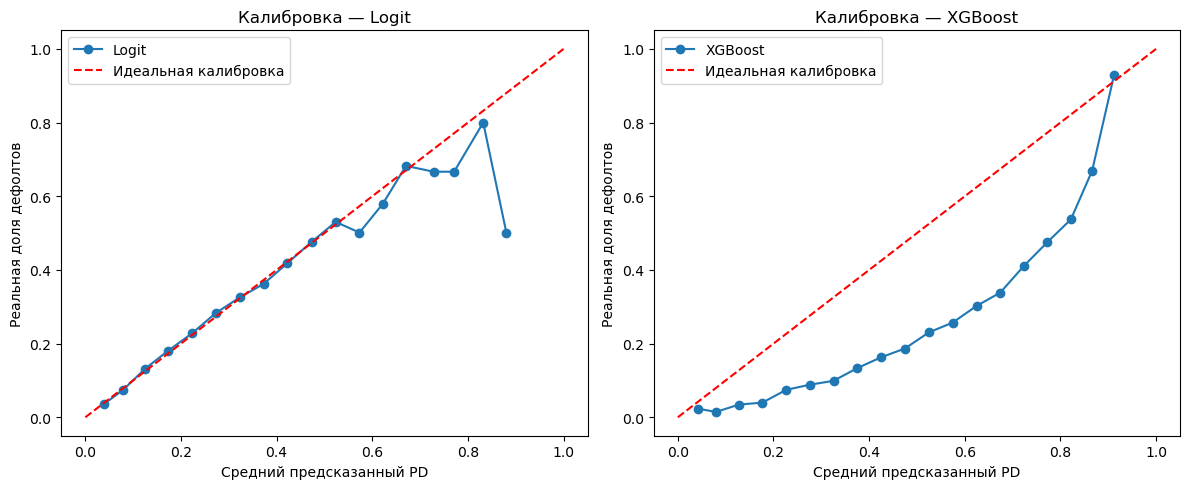

In [7]:
# калибровочная кривая
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, name in zip(
    axes,
    [df_portfolio['pd_lr'], df_portfolio['pd_xgb']],
    ['Logit', 'XGBoost']
):
    # берём подвыборку — на всём портфеле долго считать
    sample = df_portfolio.sample(50000, random_state=42)
    pd_sample = preds.loc[sample.index]
    
    fraction_pos, mean_pred = calibration_curve(
        sample['is_default'], pd_sample, n_bins=20
    )
    
    ax.plot(mean_pred, fraction_pos, 'o-', label=name)
    ax.plot([0, 1], [0, 1], 'r--', label='Идеальная калибровка')
    ax.set_xlabel('Средний предсказанный PD')
    ax.set_ylabel('Реальная доля дефолтов')
    ax.set_title(f'Калибровка — {name}')
    ax.legend()

plt.tight_layout()
plt.show()

In [8]:
df_portfolio['pd'] = df_portfolio['pd_lr']
print(f"Используем логит. Средний PD: {df_portfolio['pd'].mean():.3f}")

Используем логит. Средний PD: 0.200


In [10]:
df_portfolio['el'] = df_portfolio['pd'] * df_portfolio['lgd'] * df_portfolio['ead']

print(f"Портфельный EL:  {df_portfolio['el'].sum():>15,.0f}")
print(f"Общий EAD:       {df_portfolio['ead'].sum():>15,.0f}")
print(f"EL / EAD:        {df_portfolio['el'].sum() / df_portfolio['ead'].sum():.3f}")

Портфельный EL:    2,900,045,095
Общий EAD:        19,295,130,825
EL / EAD:        0.150


In [11]:
N_SIMULATIONS = 10_000
CONFIDENCE = 0.99
rho = 0.15  # корреляция Базель II для розничных кредитов

pds  = df_portfolio['pd'].values
lgds = df_portfolio['lgd'].values
eads = df_portfolio['ead'].values

# пороги дефолта для каждого заёмщика - считаем один раз вне цикла
K = stats.norm.ppf(pds) 

np.random.seed(42)
portfolio_losses_corr = np.zeros(N_SIMULATIONS)

for i in range(N_SIMULATIONS):
    # систематический фактор - один на весь портфель
    Z = np.random.normal(0, 1)
    # идиосинкратические шоки — один на каждого заёмщика
    epsilon = np.random.normal(0, 1, len(pds))
    # стоимость активов заёмщика
    Y = np.sqrt(rho) * Z + np.sqrt(1 - rho) * epsilon
    # дефолт если стоимость активов упала ниже порога
    defaults = (Y < K).astype(int)
    portfolio_losses_corr[i] = np.sum(defaults * lgds * eads)

el_c  = np.mean(portfolio_losses_corr)
var_c = np.percentile(portfolio_losses_corr, 99)
es_c  = portfolio_losses_corr[portfolio_losses_corr >= var_c].mean()
ul_c  = var_c - el_c

In [12]:
print(f"С корреляцией ASRF (rho={rho}):")
print(f"EL:  {el_c/1e9:.3f}B  |  VaR: {var_c/1e9:.3f}B  |  UL: {ul_c/1e9:.3f}B")
print(f"EL  / EAD: {el_c / eads.sum():.3f}")
print(f"VaR / EAD: {var_c / eads.sum():.3f}")
print(f"ES 99%: {es_c:>15,.0f}")

С корреляцией ASRF (rho=0.15):
EL:  2.898B  |  VaR: 7.006B  |  UL: 4.108B
EL  / EAD: 0.150
VaR / EAD: 0.363
ES 99%:   7,623,863,926


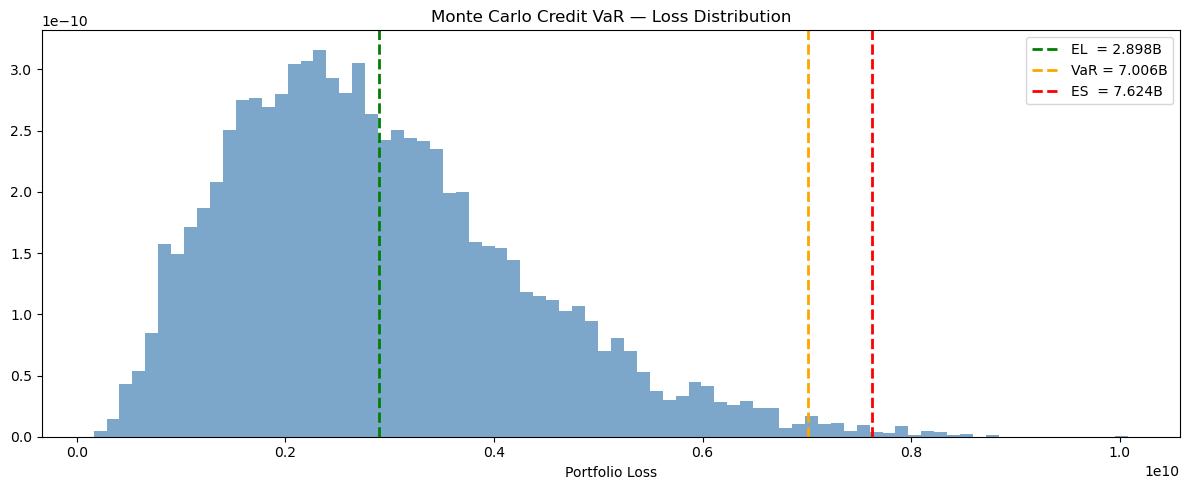

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(portfolio_losses_corr, bins=80, density=True,
        color='steelblue', alpha=0.7)

ax.axvline(el_c,  color='green',  linestyle='--',
           linewidth=2, label=f'EL  = {el_c/1e9:.3f}B')
ax.axvline(var_c, color='orange', linestyle='--',
           linewidth=2, label=f'VaR = {var_c/1e9:.3f}B')
ax.axvline(es_c,  color='red',    linestyle='--',
           linewidth=2, label=f'ES  = {es_c/1e9:.3f}B')

ax.set_xlabel('Portfolio Loss')
ax.set_title('Monte Carlo Credit VaR — Loss Distribution')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
con.execute("""
    CREATE TABLE IF NOT EXISTS mart.risk_metrics (
        run_date    DATE,
        model_name  VARCHAR,
        el          DOUBLE,
        var_99      DOUBLE,
        es_99       DOUBLE,
        ul          DOUBLE,
        el_ratio    DOUBLE,
        var_ratio   DOUBLE,
        rho         DOUBLE,
        n_sim       INTEGER
    )
""")

con.execute("""
    INSERT INTO mart.risk_metrics VALUES (
        CURRENT_DATE,
        'ASRF_logit_v2',
        ?, ?, ?, ?, ?, ?, ?, ?
    )
""", [el_c, var_c, es_c, ul_c,
      el_c / eads.sum(),
      var_c / eads.sum(),
      rho, N_SIMULATIONS])

print("Результаты сохранены в mart.risk_metrics")
con.execute("SELECT * FROM mart.risk_metrics").df()

Результаты сохранены в mart.risk_metrics


,run_date,model_name,el,var_99,es_99,ul,el_ratio,var_ratio,rho,n_sim
0,2026-04-10,ASRF_logit_v2,2.897781e+09,7.005976e+09,7.623864e+09,4.108195e+09,0.150182,0.363096,0.15,10000


In [16]:
con.close()